# Final Model

This notebook constructs the final model we will use to find the relative premium for houses in each neghborhood of Chicago. Our final model is an XGBoost regressor.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import json

In [2]:
data = pd.read_parquet(r"../Data/sale_and_crime_data/chicago_sales_with_crime.parquet")

There are several features in our final data set which we will want to exclude. These include features which encode the relative location of the houses, since we want all of the contribution of the location to be concentrated in the community area feature. We also exclude variables which have little to no predictive value and those which are mostly missing. We point the reader to the Exploring Alternate Linear Regression Models notebook in the data folder for more information.

In [3]:
features_to_exclude = ["pin","is_multisale",'flood_fema_sfha', "sale_filter_same_sale_within_365", "sale_filter_less_than_10k", "single_v_multi_family", "zip_code",
                      "longitude", "latitude", "sale_date_parsed", "class", 'centroid_x_crs_3435', 'centroid_y_crs_3435', 'pin10', 'nearest_metra_route_dist_ft', 'nearest_new_construction_pin10',
                       "school_elementary_district_name",'nearest_golf_course_dist_ft', "school_secondary_district_name", "township_code",  "neighborhood_code",'sale_filter_deed_type', 'nearest_cta_route_dist_ft',
                                 'nearest_vacant_land_pin10','airport_noise_dnl','attic_finish','census_acs5_tract_geoid', 'nearest_neighbor_1_pin10','nearest_neighbor_2_pin10','nearest_neighbor_3_pin10','sale_date_parsed','sale_date', 'sale_year']
data = data.drop(columns = features_to_exclude)

In [4]:
cat_cols = ["type_of_residence", "construction_quality", "garage_size",
            "basement_type", "ext_wall_material", "repair_condition", "basement_finish",
            "central_heating", "central_air", "community_area"]

for col in cat_cols:
    data[col] = data[col].astype("category")

We will now import our tuned hyperparameters and build our model.

In [5]:
y=data["sale_price"]
features = list(data.columns)
features.remove("sale_price")
X=data[features]

with open("hyperparameters.json", "r") as f:
    hyperparams = json.load(f)
model = xgb.XGBRegressor(
    random_state=42, 
    enable_categorical=True, 
    tree_method="hist",
    **hyperparams
)
model.fit(
    X,y,
    verbose=False
)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5371444645609915
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None
,feature_types,None


In [6]:
import matplotlib.pyplot as plt

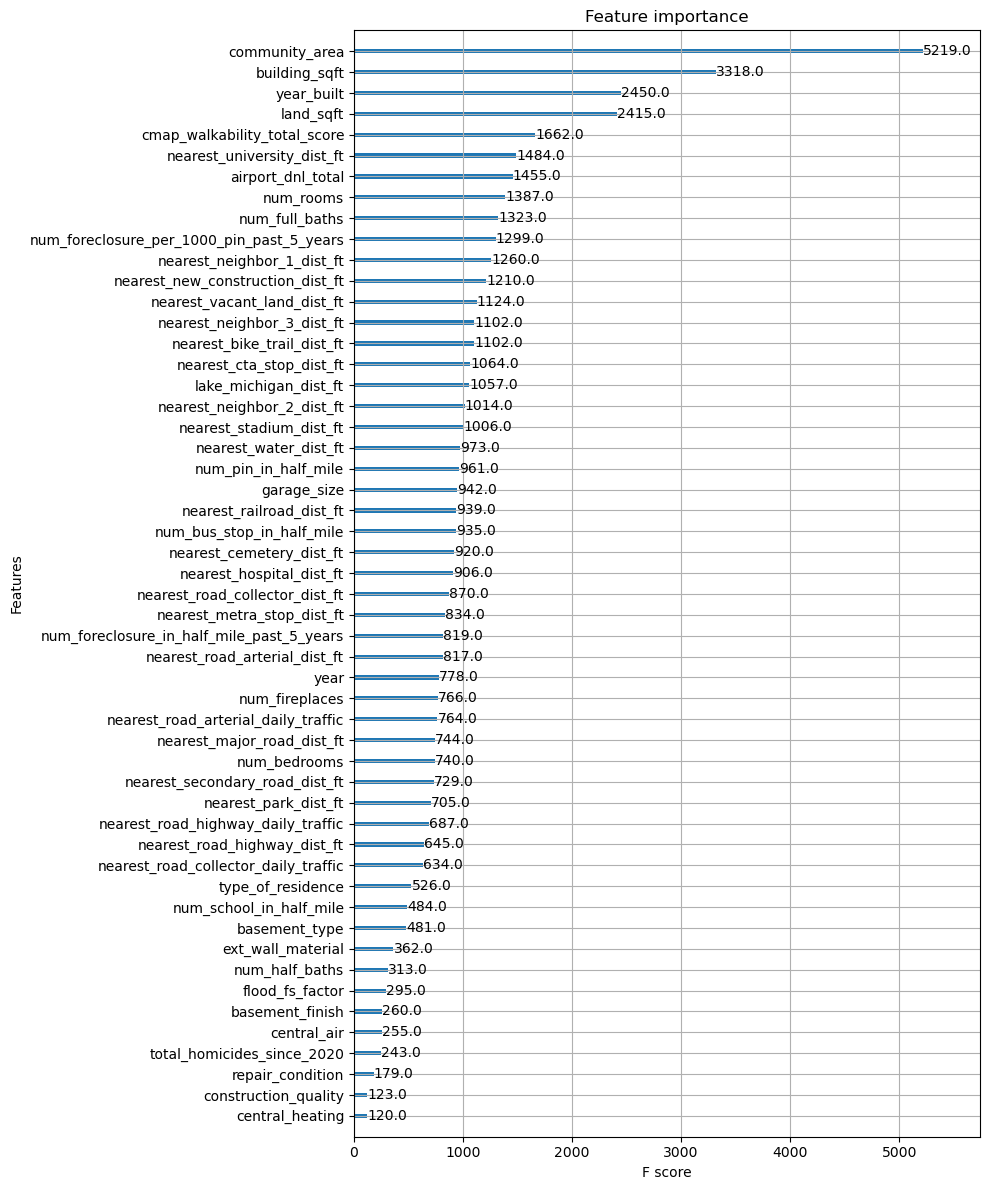

In [7]:
fig, ax = plt.subplots(figsize=(10, 12))  # wider and taller
xgb.plot_importance(model, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
def categorical_pdp(model, X, feature, categories=None):
    """
    Compute partial dependence (marginal expected value) for a categorical feature.
    
    model: fitted XGBRegressor (enable_categorical=True)
    X: DataFrame used for prediction (same columns/dtypes as training)
    feature: name of the categorical column
    categories: optional list/order of categories to evaluate; defaults to all observed categories
    """
    if categories is None:
        categories = X[feature].cat.categories if hasattr(X[feature], "cat") else X[feature].unique()

    results = []
    X_temp = X.copy()

    for cat in categories:
        X_temp[feature] = cat
        # preserve categorical dtype/categories so xgboost doesn't complain
        X_temp[feature] = X_temp[feature].astype(X[feature].dtype)
        preds = model.predict(X_temp)
        results.append({"category": cat, "mean_prediction": preds.mean(), "std_prediction": preds.std()})

    return pd.DataFrame(results).sort_values("mean_prediction", ascending=False)

pdp_data = categorical_pdp(model, X, "community_area")
pdp_data["mean_prediction"]= pdp_data["mean_prediction"]-y.mean()
print(pdp_data.to_string(index=False))

 category  mean_prediction  std_prediction
        7    415570.343750   418103.718750
        8    345278.406250   383331.093750
        6    312800.093750   398639.812500
       24    281159.468750   377561.843750
        5    254195.843750   376029.031250
       33    248442.218750   349955.812500
       41    239785.656250   365161.062500
       22    228793.093750   391947.843750
       77    221948.593750   354688.968750
        3    199751.968750   335090.343750
        4    165186.656250   346511.125000
       21    102563.468750   297067.593750
       16     93723.531250   306826.906250
       14     92840.937500   321179.375000
       12     75773.656250   294034.187500
       28     63176.781250   294629.031250
       76     54380.156250   257607.000000
        9     54164.968750   277755.718750
        1     50202.687500   261676.171875
       13     49563.187500   263629.281250
        2     43368.062500   261004.921875
       31     40496.281250   293161.031250
       39  

In [ ]:
import geopandas as gpd

#Use the Root Dataset ID (igwz-8jzy) via the standard SODA API
url_geojson = "https://data.cityofchicago.org/resource/igwz-8jzy.geojson"

chicago_map = gpd.read_file(url_geojson)

print("Columns found:", chicago_map.columns.tolist())

#Extract the community area integer
if 'area_numbe' in chicago_map.columns:
    chicago_map['community_area'] = chicago_map['area_numbe'].astype(int)
elif 'area_num_1' in chicago_map.columns:
    chicago_map['community_area'] = chicago_map['area_num_1'].astype(int)
else:
    print("Warning: Could not find the area number column.")

#Verify it worked
print(chicago_map[['community', 'community_area', 'geometry']].head())

Columns found: ['community', 'shape_area', 'area_num_1', 'area_numbe', 'shape_len', 'geometry']
        community  community_area  \
0     ROGERS PARK               1   
1      WEST RIDGE               2   
2          UPTOWN               3   
3  LINCOLN SQUARE               4   
4    NORTH CENTER               5   

                                            geometry  
0  MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ...  
1  MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ...  
2  MULTIPOLYGON (((-87.64102 41.9548, -87.644 41....  
3  MULTIPOLYGON (((-87.67441 41.9761, -87.6744 41...  
4  MULTIPOLYGON (((-87.67336 41.93234, -87.67342 ...  


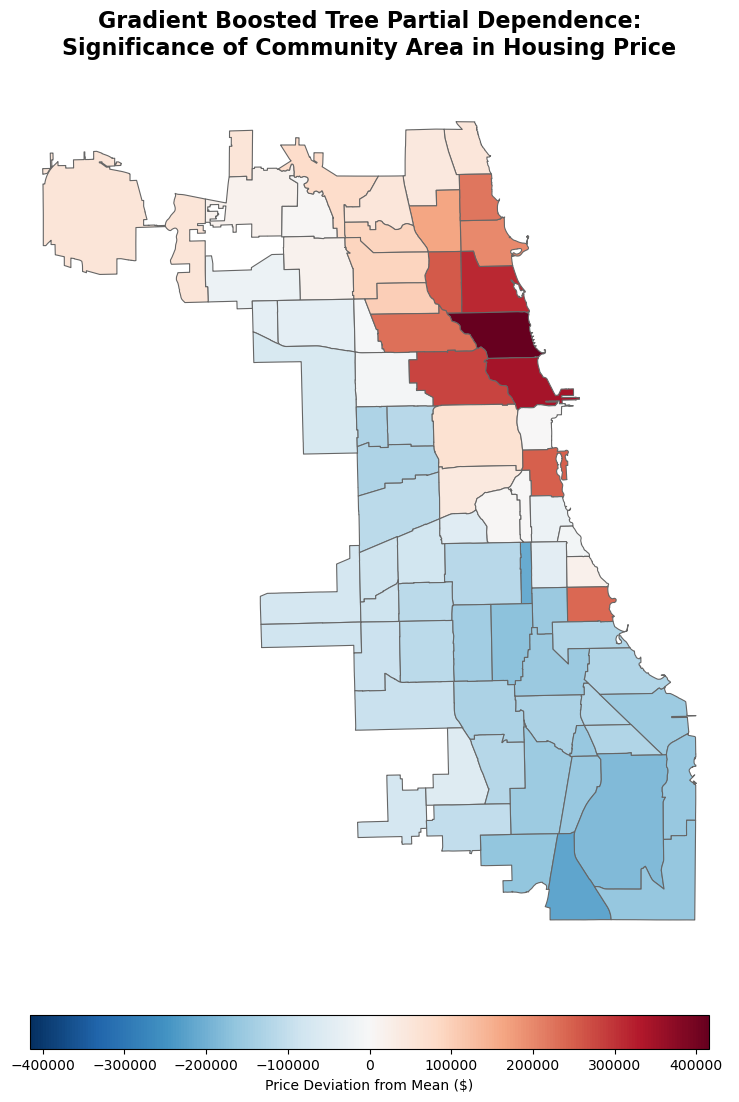

In [ ]:
import matplotlib.pyplot as plt

#Ensure the community area column is an integer to match the map IDs
pdp_data['community_area'] = pdp_data['category'].astype(int)

xgb_series = pdp_data.set_index('community_area')['mean_prediction']

#Map the centered predictions onto existing chicago_map object
chicago_map['xgb_centered_pred'] = chicago_map['community_area'].map(xgb_series)

#Fill missing areas with 0
chicago_map['xgb_centered_pred'] = chicago_map['xgb_centered_pred'].fillna(0)

#Plot the Diverging Heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

#Find the maximum absolute value to ensure $0 sits perfectly in the center of the colorbar
max_abs_val = max(chicago_map['xgb_centered_pred'].abs().max(), 0.0001)

chicago_map.plot(
    column='xgb_centered_pred', 
    cmap='RdBu_r',             
    vmin=-max_abs_val,             
    vmax=max_abs_val,              
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.4', 
    legend=True,
    legend_kwds={
        'label': "Price Deviation from Mean ($)", 
        'orientation': "horizontal", 
        'pad': 0.05, 
        'shrink': 0.7
    }
)

# Visual formatting
ax.set_title("Gradient Boosted Tree Partial Dependence:\nSignificance of Community Area in Housing Price", 
             fontsize=16, fontweight='bold', pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()